# Basic temperature model
A basic model that predicts the room temperature for a house over the next 30 hours

Variables in:
- Room temperature
- User setpoint temperature
- External temperature

Variables out:
- Room temperature

https://www.codegenes.net/blog/multivariate-lstm-pytorch/

In [99]:
import os
from datetime import datetime
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DayLocator, DateFormatter, HourLocator
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

## Preprocessing
### Load data

In [77]:
data_path = "data/PST_Data_20260220"
temperature_files = [f for f in glob(os.path.join(data_path, "*.csv")) if "Events" not in f]

In [78]:
houses_to_exclude = ['30097']

In [79]:
house_data = {}
for house_index in range(len(temperature_files)):
    house_id = temperature_files[house_index].split("/")[-1].split("_")[0]
    if house_id not in houses_to_exclude:
        # Don't include the above houses
        print('Loading data for house ID: ', house_id)
        house_df = pd.read_csv(temperature_files[house_index])
        print('Data quantity in house: ', len(house_df))
        # Store only variables needed for training
        df = pd.DataFrame({})
        # Convert time to datetime
        df['Datetime'] = [datetime.strptime(t, '%Y-%m-%d %H:%M') for t in house_df['Time (UTC)'].values]
        df['Room temperature'] = house_df['Room temperature (Zone 1) (°C)']
        df['User setpoint'] = house_df['Setpoint temperature (Zone 1) (°C)']
        df['External temperature'] = house_df['External temperature (°C)']

        house_data[house_id] = df

Loading data for house ID:  30436
Data quantity in house:  39745
Loading data for house ID:  29962
Data quantity in house:  39745
Loading data for house ID:  30568
Data quantity in house:  39745
Loading data for house ID:  30069
Data quantity in house:  39745
Loading data for house ID:  30715
Data quantity in house:  39745
Loading data for house ID:  28190
Data quantity in house:  37931
Loading data for house ID:  30668
Data quantity in house:  39745
Loading data for house ID:  30641
Data quantity in house:  39745


# Model for a house

In [81]:
house_id = '30436'
model_save_path = f"models/{house_id}_room_setpoint_50_win_1000_ep.pt"

# Extract data
house_df = house_data[house_id]

# Data cleaning - for now will just drop parts of dataframe which have NaN
house_df = house_df.dropna()
input_features = house_df[['Room temperature', 'User setpoint']].values  # 'External temperature'
target = house_df['Room temperature'].values

In [82]:
print(len(input_features))
print(len(target))

39288
39288


In [83]:
# Split the data into training and testing sets
train_end = int(len(input_features) * 0.6)
val_end = int(len(input_features) * 0.8)

# Input values
train_input = input_features[:train_end]
val_input = input_features[train_end:val_end]
test_input = input_features[val_end:]

# Target values
train_target = target[:train_end]
val_target = target[train_end:val_end]
test_target = target[val_end:]

# Test dates
test_dates = house_df["Datetime"].values[val_end:]

In [84]:
scaler = MinMaxScaler()
train_input = scaler.fit_transform(train_input)
val_input = scaler.fit_transform(val_input)
test_input = scaler.fit_transform(test_input)

In [85]:
def create_sequences(input_data, target_data, seq_length):
    """Creates sequences of seq_length steps in input data,
    predicting next step in target data"""
    inp_seq = []
    tgt_seq = []
    for i in range(len(input_data) - seq_length):
        inp_seq.append(input_data[i:i + seq_length])
        tgt_seq.append(target_data[i + seq_length])
    inp_seq = np.array(inp_seq)
    tgt_seq = np.array(tgt_seq)
    return torch.tensor(inp_seq, dtype=torch.float32), torch.tensor(tgt_seq, dtype=torch.float32)


seq_length = 10 # int((30*60)/15)
train_inp_seq, train_tgt_seq = create_sequences(train_input, train_target, seq_length)
val_inp_seq, val_tgt_seq = create_sequences(val_input, val_target, seq_length)
test_inp_seq, test_tgt_seq = create_sequences(test_input, test_target, seq_length)

In [97]:
train_inp_seq.shape

torch.Size([23562, 10, 2])

In [108]:
#Split into batches
batch_size = 5000
train_inp_batches = DataLoader(train_inp_seq, batch_size=batch_size, shuffle=True)
train_tgt_batches = DataLoader(train_tgt_seq, batch_size=batch_size, shuffle=True)

In [110]:
for i, data in enumerate(train_inp_batches):
    print(i)
    print(data.shape)

for i, data in enumerate(train_tgt_batches):
    print(i)
    print(data.shape)

0
torch.Size([5000, 10, 2])
1
torch.Size([5000, 10, 2])
2
torch.Size([5000, 10, 2])
3
torch.Size([5000, 10, 2])
4
torch.Size([3562, 10, 2])
0
torch.Size([5000])
1
torch.Size([5000])
2
torch.Size([5000])
3
torch.Size([5000])
4
torch.Size([3562])


In [86]:
class MultivariateLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(MultivariateLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

input_size = train_inp_seq.shape[2]
hidden_size = 32
num_layers = 2
output_size = 1

model = MultivariateLSTM(input_size, hidden_size, num_layers, output_size)

In [87]:
print(input_size)

2


In [88]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
training_losses = []
val_losses = []
for epoch in range(num_epochs):
    # Add minibatching -> loop over each smaller chunks of the dataset
    outputs = model(train_inp_seq)
    optimizer.zero_grad()
    training_loss = criterion(outputs, train_tgt_seq.unsqueeze(1))
    # Unsqueeze: Changes array shape from [0, 1, 2, 3] to [[0], [1], [2], [3]] to match outputs
    training_loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Training loss: {training_loss.item():.4f}')
        # Run on a validation set
        # plot loss
        with torch.no_grad():
            model.eval()
            val_preds = model(val_inp_seq)
            val_loss = criterion(val_preds, val_tgt_seq.unsqueeze(1))
            model.train()
            val_losses.append(val_loss.item())
    training_losses.append(training_loss.item())

Epoch [10/100], Training loss: 492.0240
Epoch [20/100], Training loss: 481.0836
Epoch [30/100], Training loss: 448.0889
Epoch [40/100], Training loss: 401.5170
Epoch [50/100], Training loss: 368.0009
Epoch [60/100], Training loss: 341.9492
Epoch [70/100], Training loss: 322.1487
Epoch [80/100], Training loss: 304.1870
Epoch [90/100], Training loss: 287.2984
Epoch [100/100], Training loss: 272.3126


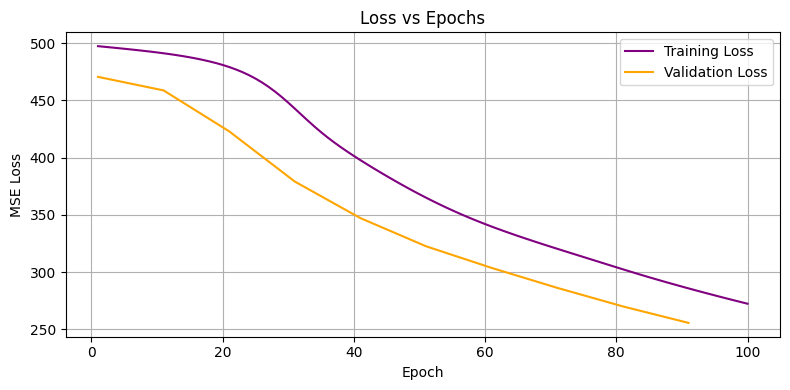

In [89]:
# Plot the loss at each epoch to visualize model convergence
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), training_losses, label='Training Loss', color='purple')
plt.plot(range(1, num_epochs + 1, 10), val_losses, label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss vs Epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

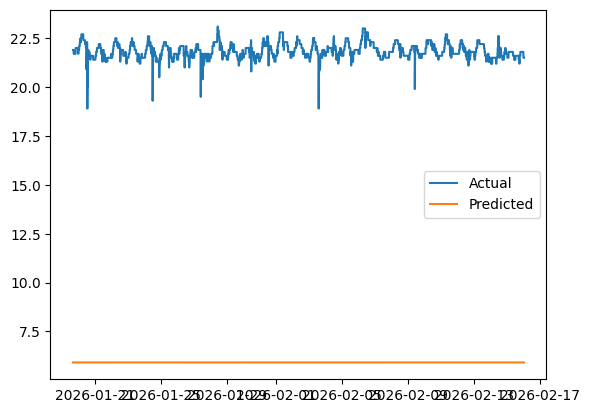

In [90]:
model.eval()
with torch.no_grad():
    test_predictions = model(test_inp_seq).numpy().flatten()

# Plot the results
plt.plot(test_dates[seq_length:], test_target[seq_length:], label='Actual')
plt.plot(test_dates[seq_length:], test_predictions, label='Predicted')
plt.legend()
plt.show()

In [91]:
test_inp_seq.shape

torch.Size([7848, 10, 2])

In [92]:
test_predictions

array([5.912316 , 5.912274 , 5.912236 , ..., 5.912543 , 5.912302 ,
       5.9122143], shape=(7848,), dtype=float32)

In [93]:
torch.save(model.state_dict(), model_save_path)

In [94]:
model = MultivariateLSTM(input_size, hidden_size, num_layers, output_size)
model.load_state_dict(torch.load(model_save_path, weights_only=True))
model.eval()

MultivariateLSTM(
  (lstm): LSTM(2, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

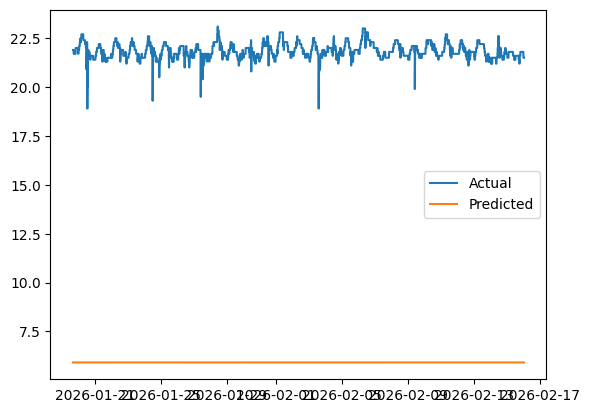

In [95]:
with torch.no_grad():
    test_predictions = model(test_inp_seq).numpy().flatten()

# Plot the results
plt.plot(test_dates[seq_length:], test_target[seq_length:], label='Actual')
plt.plot(test_dates[seq_length:], test_predictions, label='Predicted')
plt.legend()
plt.show()

In [96]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_inv, y_pred_RNN_inv, alpha=0.5, label="RNN")
plt.scatter(y_test_inv, y_pred_LSTM_inv, alpha=0.5, label="LSTM")
plt.plot([y_test_inv.min(), y_test_inv.max()], 
         [y_test_inv.min(), y_test_inv.max()], 
         'r--', lw=2)
plt.title(f'Correlation Plot (Actual vs Predicted)')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.grid(True)
plt.legend()
plt.show()

NameError: name 'y_test_inv' is not defined

<Figure size 600x600 with 0 Axes>

### Forecast

In [ ]:
# PROBLEM: predicted value is only the temperature,
# need to somehow append the true test user setpoint and ext temp to continuously forecast
# and the predicted room temp?
#
# OR does it need to predict all of these values!?
# No can't be the second one as this isn't the goal... maybe it can only do one step "blind"
# By design - only predicting temp so can't infinitely forecast unless have the next set of steps?

# AH! Our model would have ext temp forecast and user setpoint encoded in... so its okay!
# Not forecasting, just predicting next 30 hours.

### Evaluate

In [ ]:
# RMSE? MAE?